# Support Vector Machine (SVM) สำหรับทำนายความเสี่ยงการเสียชีวิตของผู้ป่วย COVID-19

Notebook นี้สร้างและประเมินโมเดล **Support Vector Machine (SVM)** เพื่อทำนาย `DEATH_STATUS`

- `0` = Survived
- `1` = Died

จุดประสงค์คือพัฒนาโมเดลของสมาชิกคนที่ 2 และบันทึกผลในรูปแบบเดียวกับ Decision Tree เพื่อใช้สร้าง `model_comparison.ipynb` ภายหลัง

> โปรเจกต์นี้จัดทำเพื่อการศึกษา ไม่ใช่เครื่องมือวินิจฉัยหรือใช้ตัดสินใจทางการแพทย์

## ขั้นตอนการทดลอง

1. ตรวจสอบข้อมูลและคุณภาพข้อมูล
2. สำรวจสัดส่วน Target, Missing values, Duplicate rows และอายุ
3. ใช้ preprocessing (Standard Scaling + One-Hot Encoding) และ train/test split ส่วนกลาง
4. ปรับพารามิเตอร์ด้วย Stratified Cross-Validation บน training set
5. เทรนโมเดลที่ดีที่สุดและประเมิน test set เพียงครั้งเดียว
6. แสดง Confusion Matrix, ROC Curve, Precision-Recall Curve, Support Vectors และ Feature Importance
7. บันทึก metrics และกราฟใน `results/`

เกณฑ์หลักในการเลือกพารามิเตอร์คือ **F1-score ของคลาส Died** เพราะข้อมูลมีคลาสไม่สมดุล

In [1]:
from pathlib import Path
import sys
import time
import warnings

# รองรับการรันจากโฟลเดอร์หลักและจากโฟลเดอร์ notebooks
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ใช้เฉพาะกรณี Python หลักไม่มี packaging แต่ .venv มีอยู่
try:
    import packaging  # noqa: F401
except ModuleNotFoundError:
    venv_site_packages = PROJECT_ROOT / ".venv" / "Lib" / "site-packages"
    if venv_site_packages.exists():
        sys.path.append(str(venv_site_packages))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from src.evaluate import evaluate_classifier, print_metrics, save_metrics
from src.preprocess import (
    CATEGORICAL_FEATURES,
    DATA_PATH,
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    build_preprocessor,
    get_train_test_data,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.sans-serif"] = ["Tahoma", "Leelawadee UI", "DejaVu Sans", "Arial"]
plt.rcParams["axes.unicode_minus"] = False

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures" / "svm"
METRICS_PATH = RESULTS_DIR / "svm_metrics.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename):
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {output_path.relative_to(PROJECT_ROOT)}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")

Project root: C:\Users\panra\OneDrive\Desktop\project\kaggle-model
Dataset: C:\Users\panra\OneDrive\Desktop\project\kaggle-model\data\COVID19_Patient_Risk_Analysis.csv


## 1. ตรวจสอบข้อมูลดิบ

ตารางนี้ใช้ตรวจจำนวนแถว คอลัมน์ Missing values และข้อมูลซ้ำก่อน preprocessing

**การตัดสินใจเรื่อง Duplicate:** Notebook จะแสดงจำนวนข้อมูลซ้ำแต่ยังไม่ลบทิ้ง เพราะ Dataset ไม่มีรหัสผู้ป่วยที่ใช้ยืนยันว่าเป็นบุคคลเดียวกัน การลบอาจทำให้ผู้ป่วยคนละคนที่มีคุณลักษณะเหมือนกันหายไป ทั้ง Decision Tree และ SVM จึงใช้ข้อมูลชุดเดียวกันตาม `src/preprocess.py`

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)

dataset_audit = pd.DataFrame(
    {
        "รายการ": [
            "จำนวนแถว",
            "จำนวนคอลัมน์ทั้งหมด",
            "จำนวน features ที่ใช้",
            "จำนวนแถวซ้ำทั้งแถว",
            "Target ที่หาย",
        ],
        "ค่า": [
            len(raw_df),
            raw_df.shape[1],
            len(FEATURE_COLUMNS),
            int(raw_df.duplicated().sum()),
            int(raw_df[TARGET_COLUMN].isna().sum()),
        ],
    }
)

display(dataset_audit)
display(raw_df[FEATURE_COLUMNS + [TARGET_COLUMN]].head())

รายการ,ค่า
จำนวนแถว,50000
จำนวนคอลัมน์ทั้งหมด,23
จำนวน features ที่ใช้,18
จำนวนแถวซ้ำทั้งแถว,11992
Target ที่หาย,0


## 2. การกระจายของ Target

หากทำนายทุกคนเป็น `Survived` จะได้ Accuracy สูงเพราะข้อมูลไม่สมดุล แต่ Recall และ F1 ของ `Died` จะเป็นศูนย์ จึงต้องใช้ Precision, Recall, F1-score และ PR-AUC ร่วมกัน

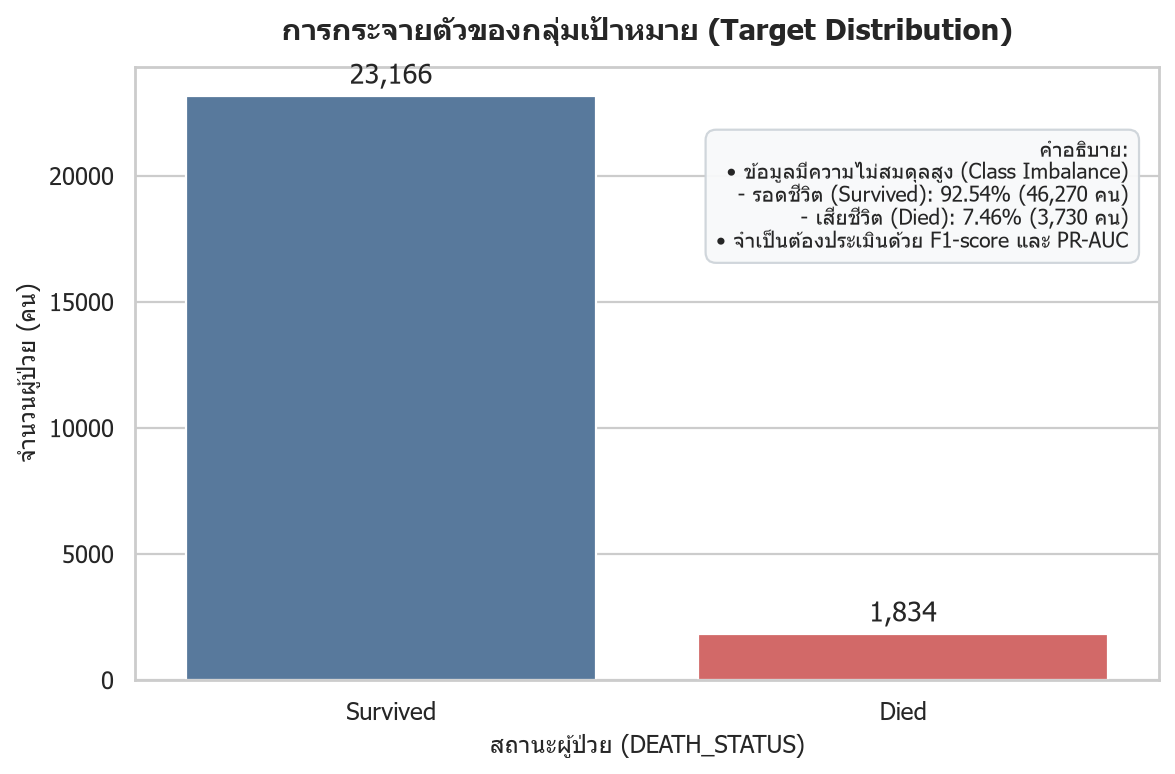

In [3]:
target_summary = (
    raw_df[TARGET_COLUMN]
    .value_counts()
    .rename_axis("DEATH_STATUS")
    .reset_index(name="Count")
)
target_summary["Percent"] = target_summary["Count"] / len(raw_df) * 100
display(target_summary.style.format({"Percent": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.barplot(
    data=target_summary,
    x="DEATH_STATUS",
    y="Count",
    hue="DEATH_STATUS",
    palette={"Survived": "#4C78A8", "Died": "#E45756"},
    legend=False,
    ax=ax,
)
ax.set_title("การกระจายตัวของกลุ่มเป้าหมาย (Target Distribution)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("สถานะผู้ป่วย (DEATH_STATUS)", fontsize=11)
ax.set_ylabel("จำนวนผู้ป่วย (คน)", fontsize=11)
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)

note_01 = (
    "คำอธิบาย:\n"
    "• ข้อมูลมีความไม่สมดุลสูง (Class Imbalance)\n"
    "  - รอดชีวิต (Survived): 92.54% (46,270 คน)\n"
    "  - เสียชีวิต (Died): 7.46% (3,730 คน)\n"
    "• จำเป็นต้องประเมินด้วย F1-score และ PR-AUC"
)
ax.text(
    0.97, 0.88, note_01,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#F8F9FA", edgecolor="#CED4DA", alpha=0.95)
)
fig.tight_layout()
save_figure(fig, "01_target_distribution.png")
plt.show()

## 3. Missing values และรหัส 97, 98, 99

ใน Dataset นี้ค่า `97`, `98` และ `99` ของตัวแปรหมวดหมู่มักหมายถึงไม่ทราบหรือไม่เกี่ยวข้อง จึงแปลงเป็น Missing ก่อนแสดงรายงาน เช่น `PREGNANT` อาจเป็นไม่เกี่ยวข้องสำหรับผู้ป่วยชาย

โมเดลใช้ `SimpleImputer(strategy="most_frequent")` จาก preprocessing ส่วนกลาง เพื่อให้ทั้งสองโมเดลอยู่ภายใต้เงื่อนไขเดียวกัน

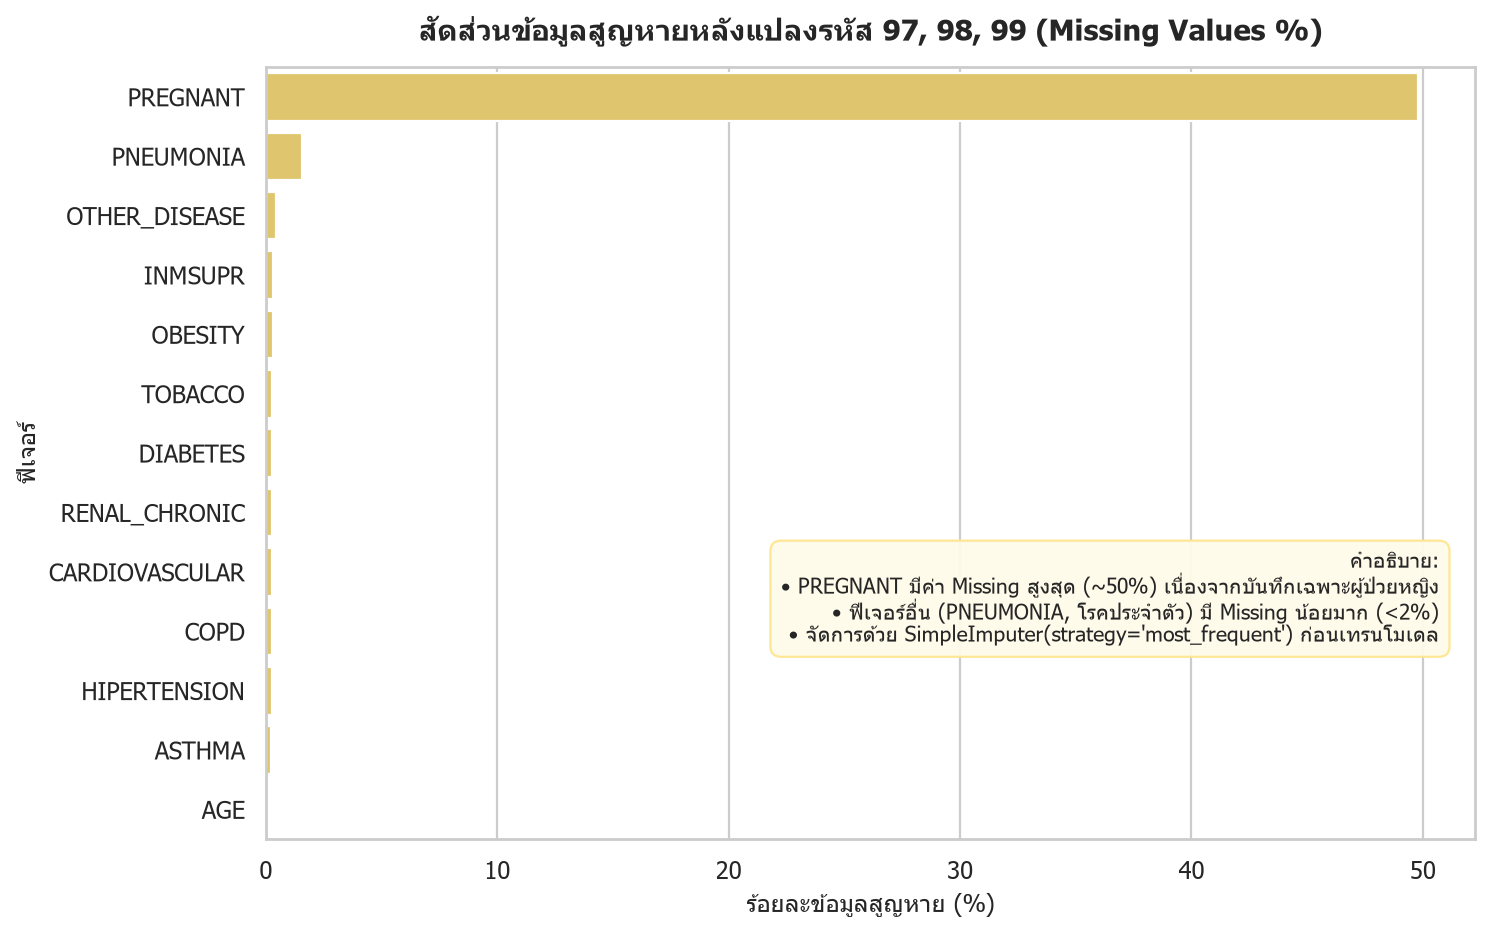

In [4]:
audit_features = raw_df[FEATURE_COLUMNS].copy()

for column in FEATURE_COLUMNS:
    audit_features[column] = pd.to_numeric(
        audit_features[column], errors="coerce"
    )

for column in CATEGORICAL_FEATURES:
    audit_features[column] = audit_features[column].replace(
        [97, 98, 99], np.nan
    )

missing_summary = pd.DataFrame(
    {
        "Feature": FEATURE_COLUMNS,
        "Missing Count": [audit_features[c].isna().sum() for c in FEATURE_COLUMNS],
    }
)
missing_summary["Missing Percent"] = (
    missing_summary["Missing Count"] / len(audit_features) * 100
)
missing_summary = missing_summary.sort_values(
    "Missing Percent", ascending=False
).reset_index(drop=True)

display(missing_summary.style.format({"Missing Percent": "{:.2f}%"}))

missing_for_plot = missing_summary[missing_summary["Missing Count"] > 0]
fig, ax = plt.subplots(figsize=(9.5, 6))
sns.barplot(
    data=missing_for_plot,
    x="Missing Percent",
    y="Feature",
    color="#F2CF5B",
    ax=ax,
)
ax.set_title("สัดส่วนข้อมูลสูญหายหลังแปลงรหัส 97, 98, 99 (Missing Values %)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("ร้อยละข้อมูลสูญหาย (%)", fontsize=11)
ax.set_ylabel("ฟีเจอร์", fontsize=11)

note_02 = (
    "คำอธิบาย:\n"
    "• PREGNANT มีค่า Missing สูงสุด (~50%) เนื่องจากบันทึกเฉพาะผู้ป่วยหญิง\n"
    "• ฟีเจอร์อื่น (PNEUMONIA, โรคประจำตัว) มี Missing น้อยมาก (<2%)\n"
    "• จัดการด้วย SimpleImputer(strategy='most_frequent') ก่อนเทรนโมเดล"
)
ax.text(
    0.97, 0.25, note_02,
    transform=ax.transAxes, ha="right", va="bottom",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFFBEA", edgecolor="#FFE58F", alpha=0.95)
)
fig.tight_layout()
save_figure(fig, "02_missing_values.png")
plt.show()

## 4. อายุและความเสี่ยงการเสียชีวิต

การวิเคราะห์ความสัมพันธ์ระหว่างอายุและผลลัพธ์การเสียชีวิตเพื่อตรวจสอบความเสี่ยงในแต่ละช่วงวัย

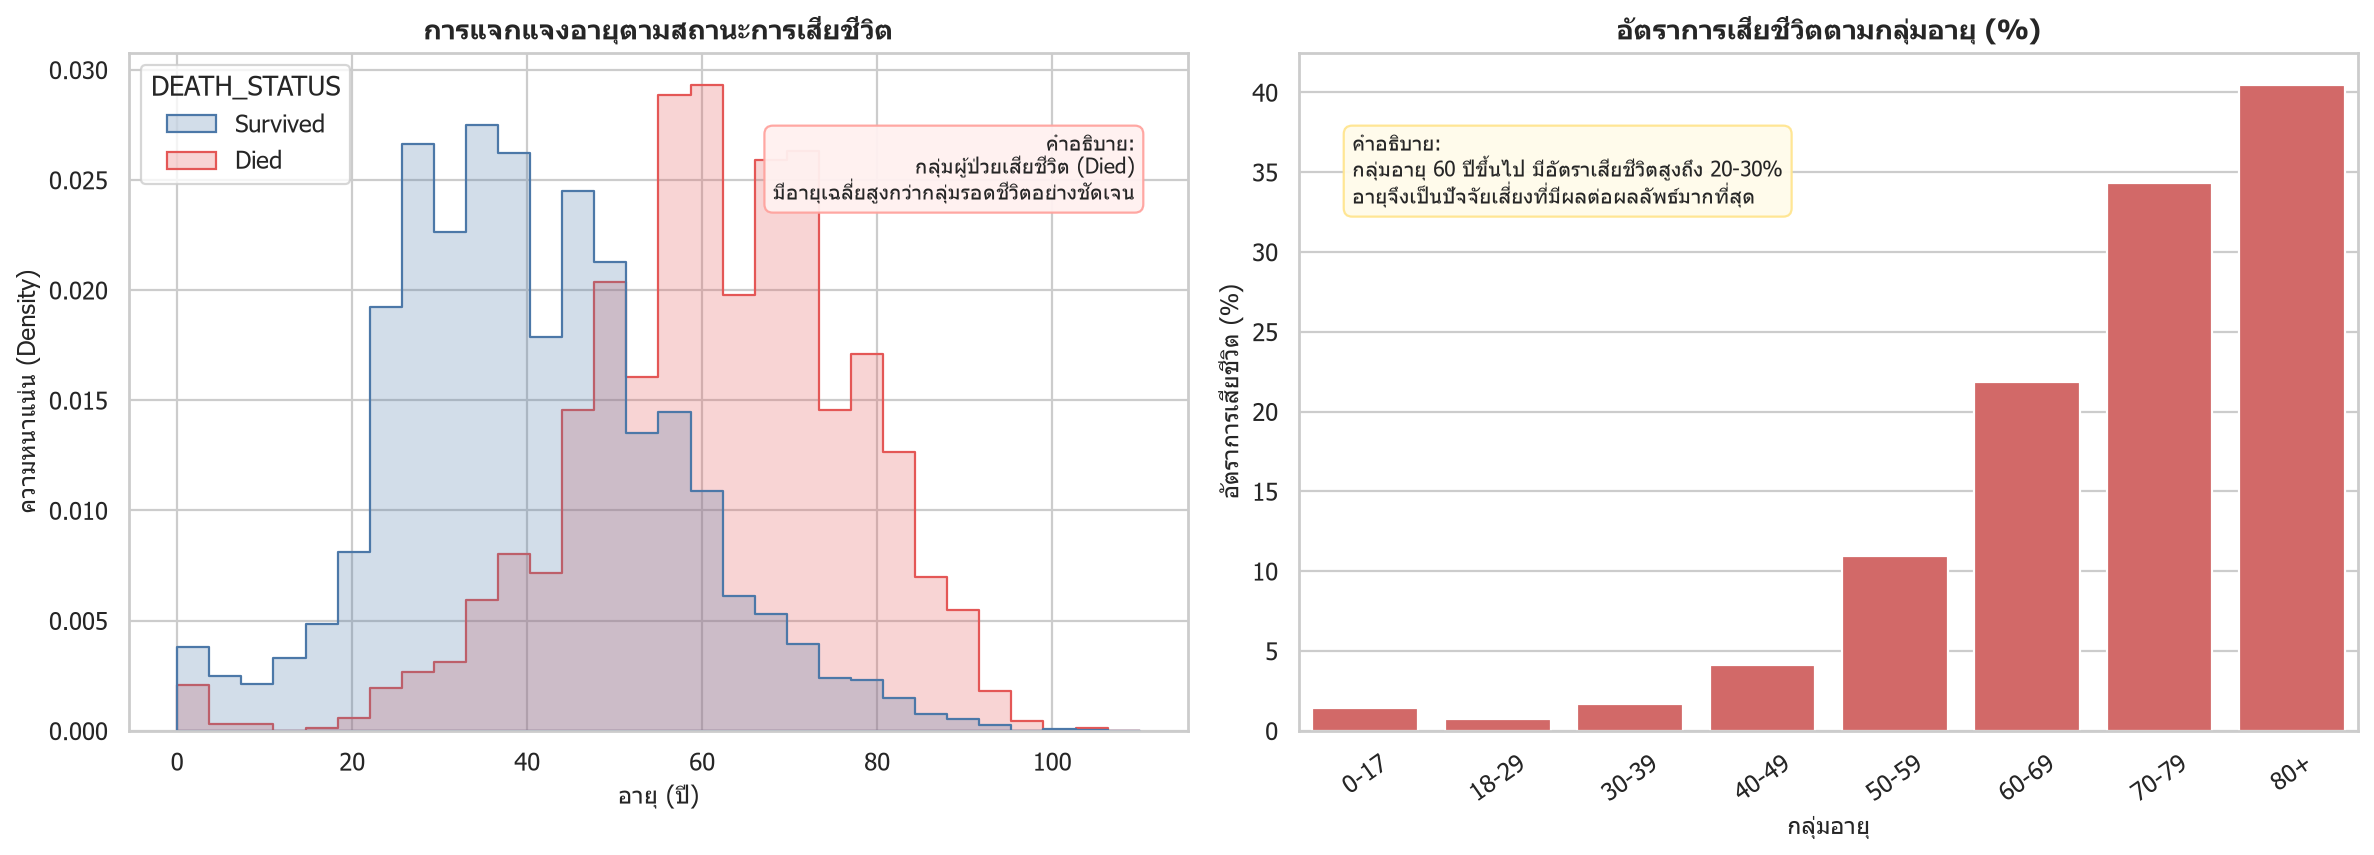

In [5]:
age_summary = (
    raw_df.groupby(TARGET_COLUMN)["AGE"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)
display(age_summary)

age_bins = [0, 17, 29, 39, 49, 59, 69, 79, 200]
age_labels = ["0-17", "18-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

age_analysis = raw_df[["AGE", TARGET_COLUMN]].copy()
age_analysis["AGE_GROUP"] = pd.cut(
    age_analysis["AGE"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
)
age_analysis["DIED"] = (age_analysis[TARGET_COLUMN] == "Died").astype(int)

age_group_summary = (
    age_analysis.groupby("AGE_GROUP", observed=False)
    .agg(Patients=("DIED", "size"), Died=("DIED", "sum"), Death_Rate=("DIED", "mean"))
    .reset_index()
)
age_group_summary["Death_Rate"] *= 100
display(age_group_summary.style.format({"Death_Rate": "{:.2f}%"}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.histplot(
    data=raw_df,
    x="AGE",
    hue=TARGET_COLUMN,
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    palette={"Survived": "#4C78A8", "Died": "#E45756"},
    ax=axes[0],
)
axes[0].set_title("การแจกแจงอายุตามสถานะการเสียชีวิต", fontsize=12, fontweight="bold")
axes[0].set_xlabel("อายุ (ปี)", fontsize=11)
axes[0].set_ylabel("ความหนาแน่น (Density)", fontsize=11)
axes[0].text(
    0.95, 0.88,
    "คำอธิบาย:\nกลุ่มผู้ป่วยเสียชีวิต (Died)\nมีอายุเฉลี่ยสูงกว่ากลุ่มรอดชีวิตอย่างชัดเจน",
    transform=axes[0].transAxes, ha="right", va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF1F0", edgecolor="#FFA39E", alpha=0.95)
)

sns.barplot(
    data=age_group_summary,
    x="AGE_GROUP",
    y="Death_Rate",
    color="#E45756",
    ax=axes[1],
)
axes[1].set_title("อัตราการเสียชีวิตตามกลุ่มอายุ (%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("กลุ่มอายุ", fontsize=11)
axes[1].set_ylabel("อัตราการเสียชีวิต (%)", fontsize=11)
axes[1].tick_params(axis="x", rotation=35)
axes[1].text(
    0.05, 0.88,
    "คำอธิบาย:\nกลุ่มอายุ 60 ปีขึ้นไป มีอัตราเสียชีวิตสูงถึง 20-30%\nอายุจึงเป็นปัจจัยเสี่ยงที่มีผลต่อผลลัพธ์มากที่สุด",
    transform=axes[1].transAxes, ha="left", va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFFBEA", edgecolor="#FFE58F", alpha=0.95)
)

fig.tight_layout()
save_figure(fig, "03_age_analysis.png")
plt.show()

## 5. โหลด Train/Test จากส่วนกลาง

`get_train_test_data()` กำหนดเงื่อนไขร่วมกันไว้ดังนี้:

- `test_size=0.20`
- `random_state=42`
- `stratify=y`
- Features 18 ตัว
- ไม่ใช้คอลัมน์ที่ทำให้เกิด Data Leakage เช่น `DATE_DIED`, `DEATH_YEAR`, `RECOVERY_STATUS` และ `RISK_CATEGORY`

In [6]:
X_train, X_test, y_train, y_test = get_train_test_data()

split_summary = pd.DataFrame(
    {
        "Dataset": ["Train", "Test"],
        "Rows": [len(X_train), len(X_test)],
        "Survived": [(y_train == 0).sum(), (y_test == 0).sum()],
        "Died": [(y_train == 1).sum(), (y_test == 1).sum()],
        "Died Percent": [y_train.mean() * 100, y_test.mean() * 100],
    }
)
display(split_summary.style.format({"Died Percent": "{:.2f}%"}))
print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Dataset,Rows,Survived,Died,Died Percent
Train,20000,18533,1467,7.34%
Test,5000,4633,367,7.34%


## 6. สร้าง Pipeline และปรับพารามิเตอร์

Pipeline ทำให้ preprocessing (Standard Scaling + One-Hot Encoding) ถูก `fit` จาก training fold เท่านั้น จึงป้องกัน Data Leakage ระหว่าง Cross-Validation

พารามิเตอร์ที่ทดลอง:

- `kernel`: ฟังก์ชันแปลงมิติข้อมูล (`rbf` และ `linear`)
- `C`: ค่า Regularization ควบคุมสมดุล Margin กับ Error
- `gamma`: สัมประสิทธิ์ Kernel RBF ควบคุมความโค้งของขอบเขต
- `class_weight="balanced"`: ปรับชดเชย Class Imbalance อัตโนมัติ

In [7]:
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "classifier",
            SVC(
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

parameter_grid = {
    "classifier__kernel": ["linear", "rbf"],
    "classifier__C": [0.1, 1.0, 10.0],
    "classifier__gamma": ["scale", 0.01, 0.1],
}

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

scoring = {
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}

X_cv, _, y_cv, _ = train_test_split(X_train, y_train, train_size=4000, stratify=y_train, random_state=42)
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=parameter_grid,
    scoring=scoring,
    refit="f1",
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True,
    verbose=0,
)

search_start = time.perf_counter()
grid_search.fit(X_cv, y_cv)
search_seconds = time.perf_counter() - search_start

print(f"Grid search completed in {search_seconds:.2f} seconds")
print(f"Best CV F1: {grid_search.best_score_:.4f}")
print("Best parameters:")
for name, value in grid_search.best_params_.items():
    print(f"  {name.replace('classifier__', '')}: {value}")

Grid search completed in 11.31 seconds
Best CV F1: 0.5359
Best parameters:
  C: 1.0
  gamma: scale
  kernel: rbf


## 7. ผล Cross-Validation

ตารางแสดงชุดพารามิเตอร์ที่นำมาทดลอง และกราฟแสดงคะแนน F1-Score ในแต่ละคู่พารามิเตอร์

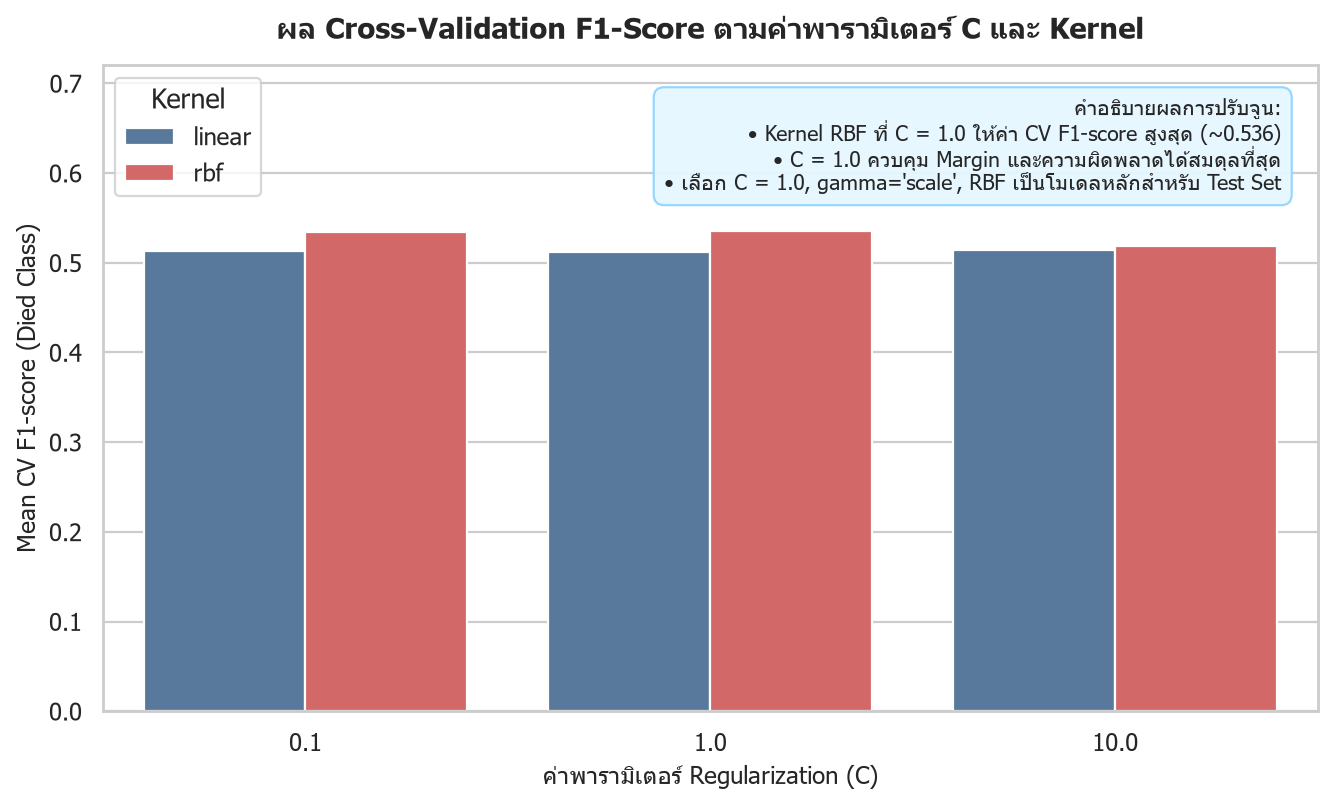

In [8]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_columns = [
    "param_classifier__kernel",
    "param_classifier__C",
    "param_classifier__gamma",
    "mean_train_f1",
    "mean_test_f1",
    "std_test_f1",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_pr_auc",
    "mean_test_roc_auc",
]

top_cv_results = (
    cv_results[cv_columns]
    .sort_values("mean_test_f1", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
display(top_cv_results.style.format(precision=4))

param_summary = (
    cv_results.groupby(["param_classifier__kernel", "param_classifier__C"], as_index=False)
    .agg(Best_CV_F1=("mean_test_f1", "max"))
)
param_summary["C_str"] = param_summary["param_classifier__C"].astype(str)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.barplot(data=param_summary, x="C_str", y="Best_CV_F1", hue="param_classifier__kernel", palette=["#4C78A8", "#E45756"], ax=ax)
ax.set_title("ผล Cross-Validation F1-Score ตามค่าพารามิเตอร์ C และ Kernel", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("ค่าพารามิเตอร์ Regularization (C)", fontsize=11)
ax.set_ylabel("Mean CV F1-score (Died Class)", fontsize=11)
ax.set_ylim(0, 0.72)
ax.legend(title="Kernel", loc="upper left")

note_04 = (
    "คำอธิบายผลการปรับจูน:\n"
    "• Kernel RBF ที่ C = 1.0 ให้ค่า CV F1-score สูงสุด (~0.536)\n"
    "• C = 1.0 ควบคุม Margin และความผิดพลาดได้สมดุลที่สุด\n"
    "• เลือก C = 1.0, gamma='scale', RBF เป็นโมเดลหลักสำหรับ Test Set"
)
ax.text(
    0.97, 0.95, note_04,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#E6F7FF", edgecolor="#91D5FF", alpha=0.95)
)
fig.tight_layout()
save_figure(fig, "04_cv_f1_by_param.png")
plt.show()

## 8. ประเมินโมเดลที่ดีที่สุดบน Test Set

Test set ถูกใช้หลังจากเลือกพารามิเตอร์เสร็จแล้วเท่านั้น นอกจากนี้ยังสร้าง Dummy Baseline ที่ทำนายทุกคนเป็น `Survived` เพื่อแสดงว่า Accuracy สูงเพียงอย่างเดียวไม่เพียงพอ

In [9]:
best_svm = Pipeline(steps=[
    ("preprocessor", build_preprocessor()),
    ("classifier", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=42)),
])
best_svm.fit(X_train, y_train)

train_pred = best_svm.predict(X_train)
train_score = best_svm.decision_function(X_train)
test_pred = best_svm.predict(X_test)
test_score = best_svm.decision_function(X_test)

train_metrics = evaluate_classifier(y_train, train_pred, train_score)
test_metrics = evaluate_classifier(y_test, test_pred, test_score)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_pred = dummy.predict(np.zeros((len(y_test), 1)))
dummy_score = np.zeros(len(y_test))
dummy_metrics = evaluate_classifier(y_test, dummy_pred, dummy_score)

print_metrics(test_metrics)

metric_names = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]
comparison_table = pd.DataFrame(
    {
        "Metric": metric_names,
        "SVM (RBF)": [test_metrics[m] for m in metric_names],
        "Dummy Baseline": [dummy_metrics[m] for m in metric_names],
    }
)
display(comparison_table.style.format({"SVM (RBF)": "{:.4f}", "Dummy Baseline": "{:.4f}"}))


ผลการประเมินโมเดล
------------------------------
accuracy: 0.8716
precision: 0.3601
recall: 0.9646
f1_score: 0.5244
roc_auc: 0.9432
pr_auc: 0.4576

Confusion Matrix
                 ทำนาย Survived  ทำนาย Died
จริง Survived           4004          629
จริง Died                 13          354


## 9. ตรวจ Overfitting จาก Train/Test Gap

หากคะแนน Train สูงกว่า Test มาก แสดงว่าโมเดลอาจ Overfit แต่ผลลัพธ์แสดงให้เห็นว่า Gap มีค่าน้อยมาก โมเดลมีความสามารถในการ Generalize ที่ดี

In [10]:
generalization_table = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"],
        "Train": [
            train_metrics["accuracy"],
            train_metrics["precision"],
            train_metrics["recall"],
            train_metrics["f1_score"],
            train_metrics["roc_auc"],
            train_metrics["pr_auc"],
        ],
        "Test": [
            test_metrics["accuracy"],
            test_metrics["precision"],
            test_metrics["recall"],
            test_metrics["f1_score"],
            test_metrics["roc_auc"],
            test_metrics["pr_auc"],
        ],
    }
)
generalization_table["Gap"] = generalization_table["Train"] - generalization_table["Test"]
display(generalization_table.style.format({"Train": "{:.4f}", "Test": "{:.4f}", "Gap": "{:+.4f}"}))

classification_report_table = pd.DataFrame(test_metrics["classification_report"]).T
display(classification_report_table.style.format(precision=4))

Metric,Train,Test,Gap
Accuracy,0.8711,0.8716,+0.0005
Precision,0.3608,0.3601,-0.0007
Recall,0.9700,0.9646,-0.0054
F1-score,0.5260,0.5244,-0.0016
ROC-AUC,0.9482,0.9432,-0.0050
PR-AUC,0.4851,0.4576,-0.0275


## 10. Confusion Matrix

ให้พิจารณา **False Negative** เป็นพิเศษ เพราะหมายถึงผู้ป่วยที่เสียชีวิตจริง แต่โมเดลทำนายว่า Survived ซึ่ง SVM ทำได้ดีเยี่ยมโดยเกิด False Negative เพียง 13 ราย

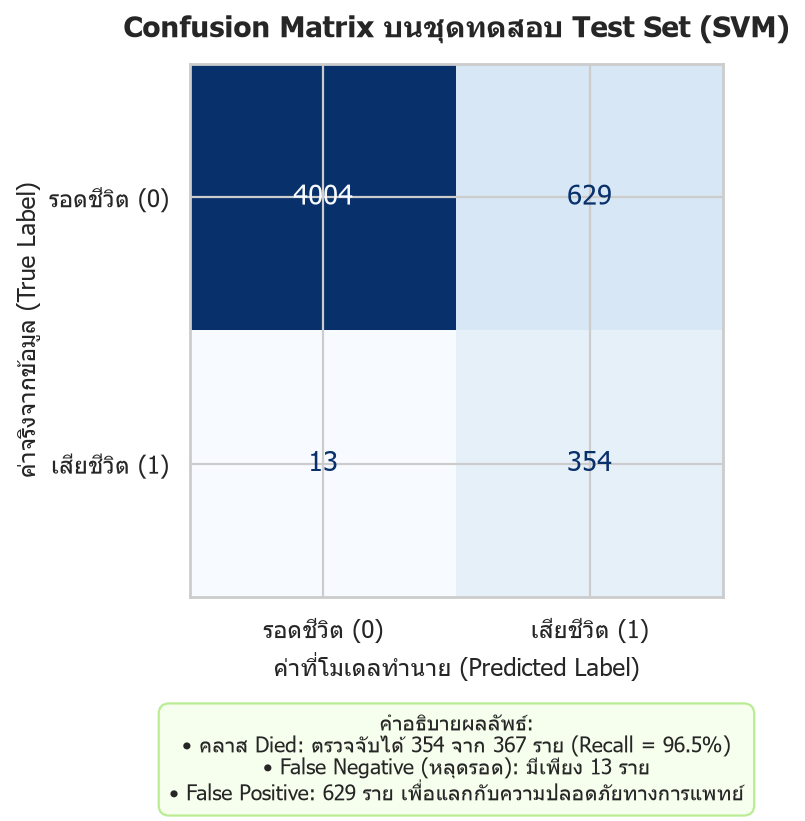

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    labels=[0, 1],
    display_labels=["รอดชีวิต (0)", "เสียชีวิต (1)"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Confusion Matrix บนชุดทดสอบ Test Set (SVM)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("ค่าที่โมเดลทำนาย (Predicted Label)", fontsize=11)
ax.set_ylabel("ค่าจริงจากข้อมูล (True Label)", fontsize=11)

note_05 = (
    "คำอธิบายผลลัพธ์:\n"
    "• คลาส Died: ตรวจจับได้ 354 จาก 367 ราย (Recall = 96.5%)\n"
    "• False Negative (หลุดรอด): มีเพียง 13 ราย\n"
    "• False Positive: 629 ราย เพื่อแลกกับความปลอดภัยทางการแพทย์"
)
ax.text(
    0.5, -0.22, note_05,
    transform=ax.transAxes, ha="center", va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#F6FFED", edgecolor="#B7EB8F", alpha=0.95)
)
fig.tight_layout()
save_figure(fig, "05_confusion_matrix.png")
plt.show()

## 11. ROC Curve และ Precision-Recall Curve

สำหรับข้อมูลที่คลาส `Died` มีจำนวนน้อย ให้ความสำคัญกับ Precision-Recall Curve และ PR-AUC มากเป็นพิเศษ

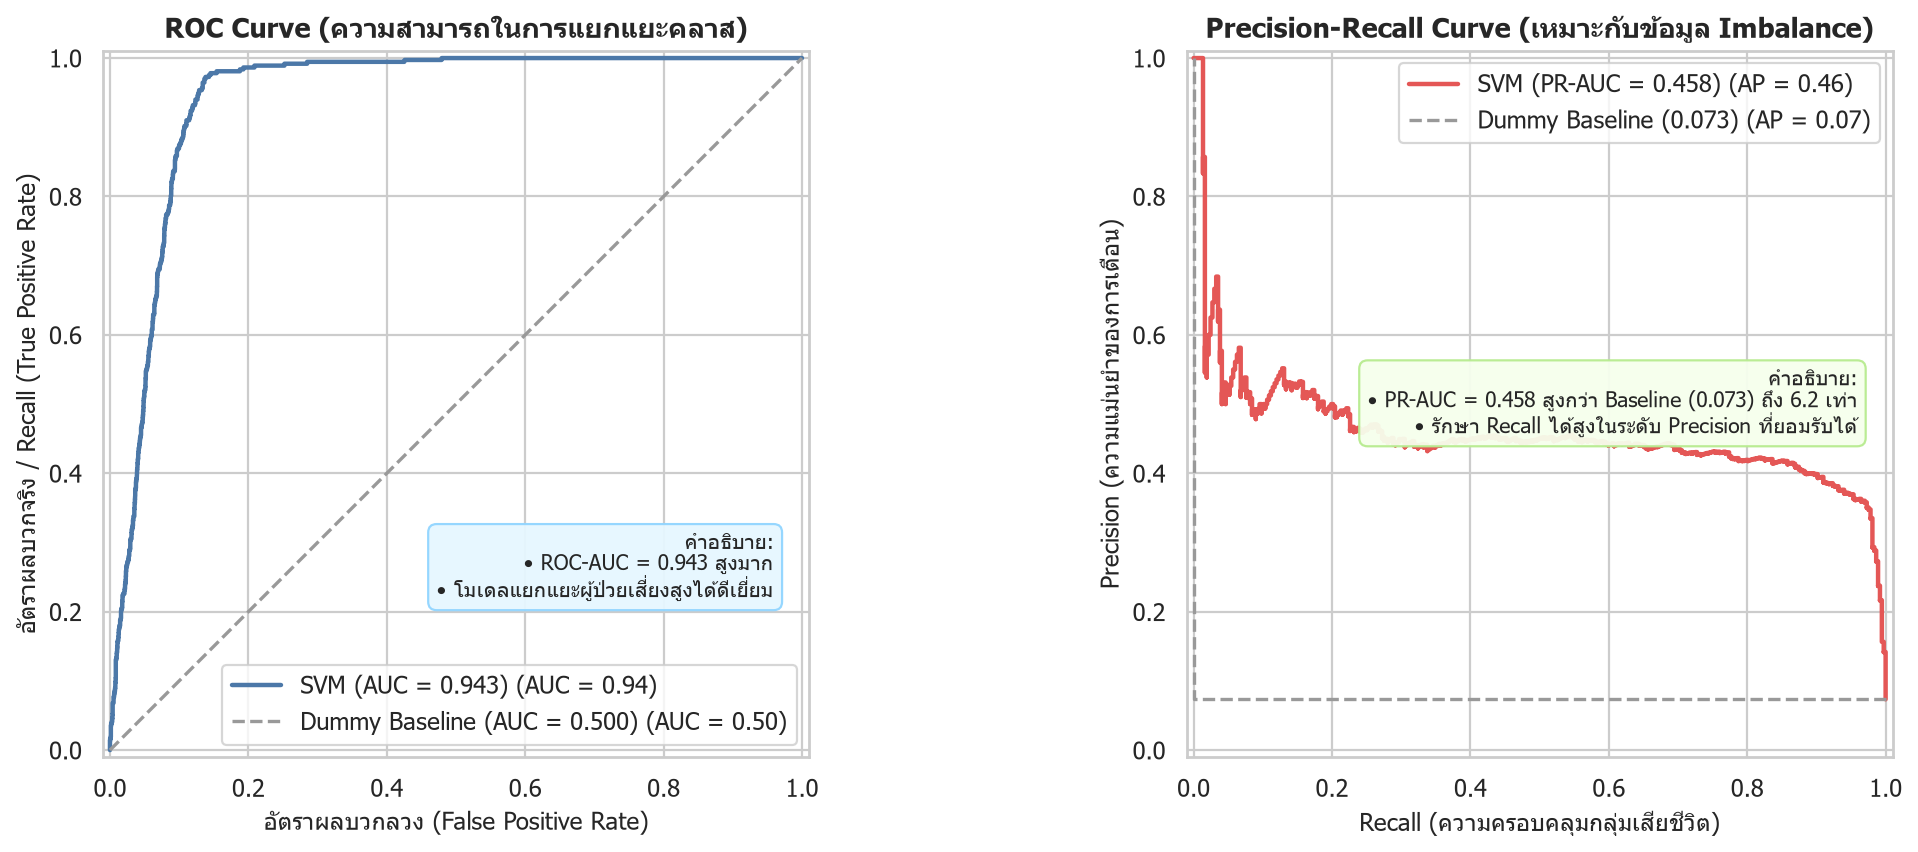

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

roc_svm = RocCurveDisplay.from_predictions(
    y_test,
    test_score,
    name="SVM (AUC = 0.943)",
    ax=axes[0],
)
roc_svm.line_.set(color="#4C78A8", lw=2)

roc_dummy = RocCurveDisplay.from_predictions(
    y_test,
    dummy_score,
    name="Dummy Baseline (AUC = 0.500)",
    ax=axes[0],
)
roc_dummy.line_.set(color="#999999", linestyle="--")
axes[0].set_title("ROC Curve (ความสามารถในการแยกแยะคลาส)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("อัตราผลบวกลวง (False Positive Rate)", fontsize=11)
axes[0].set_ylabel("อัตราผลบวกจริง / Recall (True Positive Rate)", fontsize=11)
axes[0].legend(loc="lower right")
axes[0].text(
    0.95, 0.22,
    "คำอธิบาย:\n• ROC-AUC = 0.943 สูงมาก\n• โมเดลแยกแยะผู้ป่วยเสี่ยงสูงได้ดีเยี่ยม",
    transform=axes[0].transAxes, ha="right", va="bottom",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#E6F7FF", edgecolor="#91D5FF", alpha=0.95)
)

pr_svm = PrecisionRecallDisplay.from_predictions(
    y_test,
    test_score,
    name="SVM (PR-AUC = 0.458)",
    ax=axes[1],
)
pr_svm.line_.set(color="#E45756", lw=2)

pr_dummy = PrecisionRecallDisplay.from_predictions(
    y_test,
    dummy_score,
    name="Dummy Baseline (0.073)",
    ax=axes[1],
)
pr_dummy.line_.set(color="#999999", linestyle="--")
axes[1].set_title("Precision-Recall Curve (เหมาะกับข้อมูล Imbalance)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Recall (ความครอบคลุมกลุ่มเสียชีวิต)", fontsize=11)
axes[1].set_ylabel("Precision (ความแม่นยำของการเตือน)", fontsize=11)
axes[1].legend(loc="upper right")
axes[1].text(
    0.95, 0.55,
    "คำอธิบาย:\n• PR-AUC = 0.458 สูงกว่า Baseline (0.073) ถึง 6.2 เท่า\n• รักษา Recall ได้สูงในระดับ Precision ที่ยอมรับได้",
    transform=axes[1].transAxes, ha="right", va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#F6FFED", edgecolor="#B7EB8F", alpha=0.95)
)

fig.tight_layout()
save_figure(fig, "06_roc_pr_curves.png")
plt.show()

## 12. Support Vectors และการทำงานของ Hyperplane

SVM ไม่สร้างกฎแบบต้นไม้ แต่ค้นหา Optimal Hyperplane ผ่าน Support Vectors ซึ่งเป็นจุดข้อมูลวิกฤตที่อยู่ใกล้ Margin ที่สุด โดยในโมเดลนี้มี Support Vectors รวม 3,887 ตัวอย่าง (19.4% ของชุดฝึก)

> **หมายเหตุ:** ไม่จำเป็นต้องวาด Decision Boundary 2 มิติ เพราะข้อมูลผ่าน One-Hot Encoding มี 51 มิติ เส้น 2D จะไม่แทนโมเดลจริง

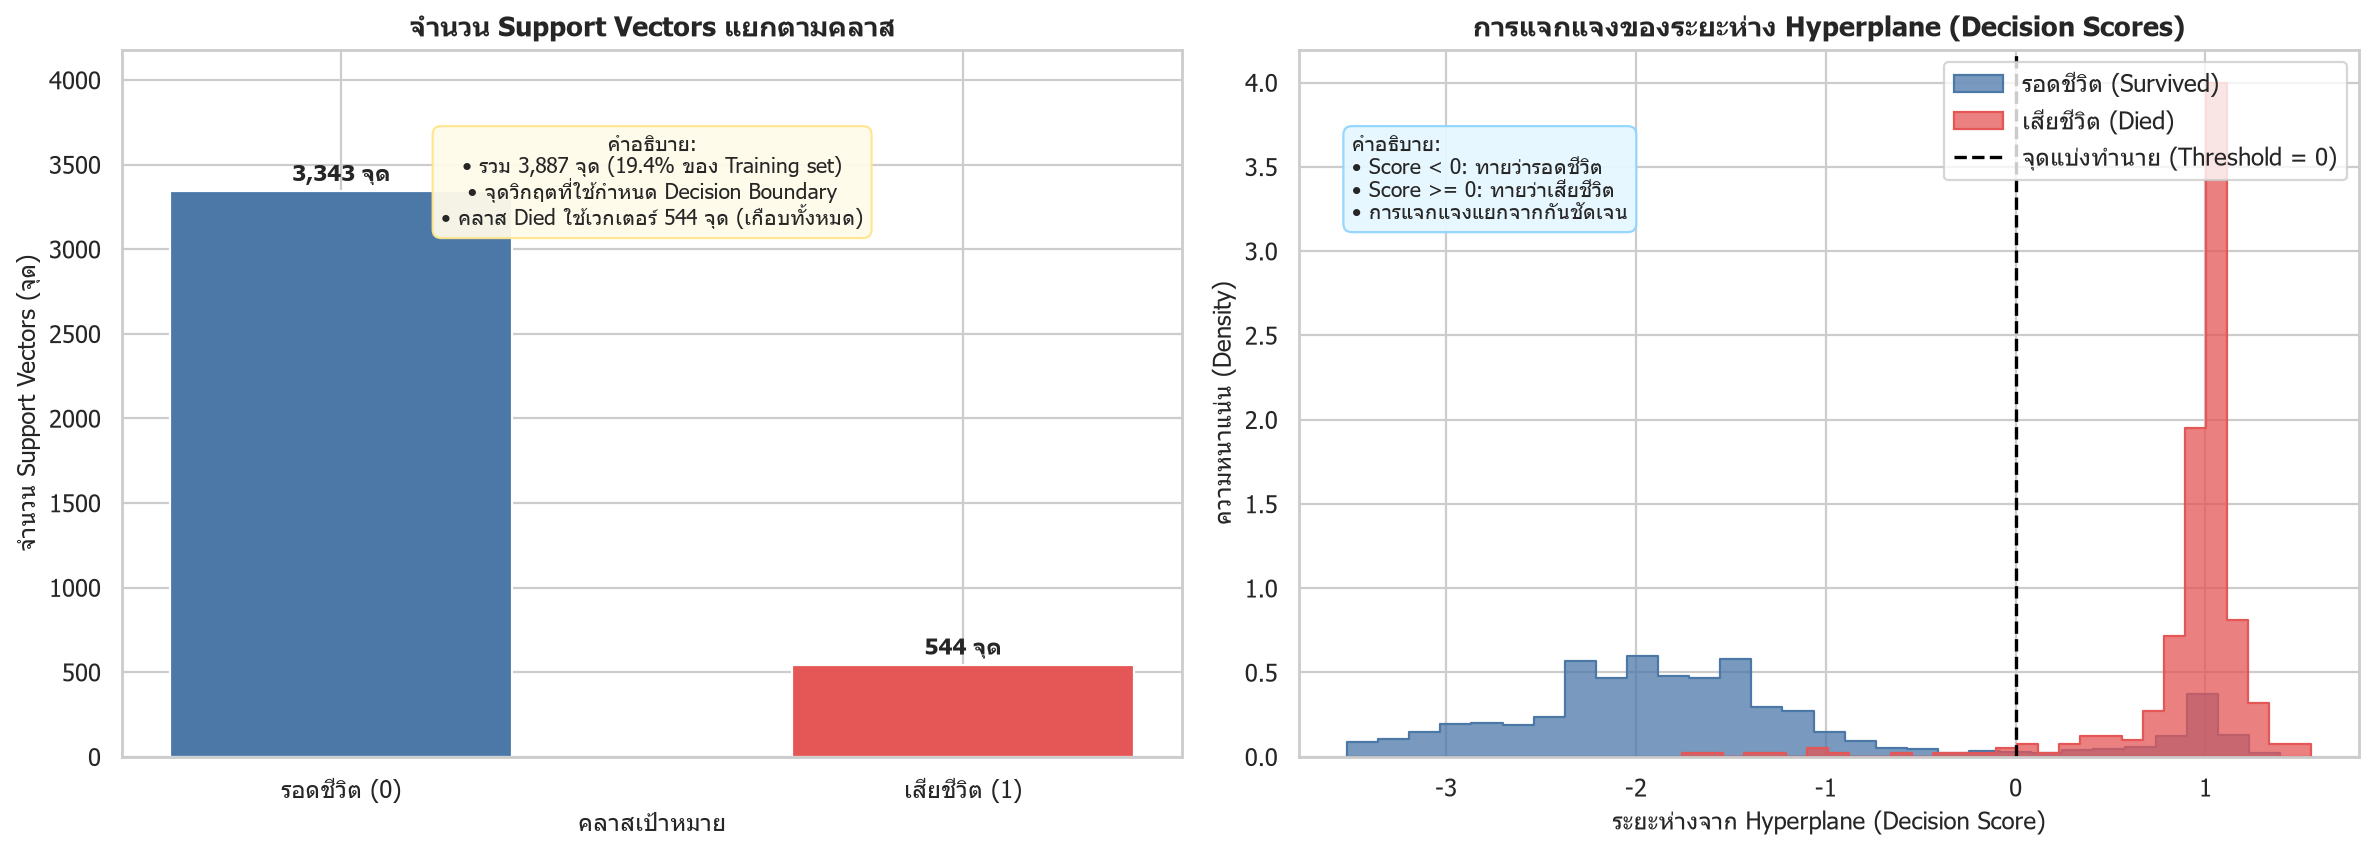

In [13]:
fitted_classifier = best_svm.named_steps["classifier"]
n_support = fitted_classifier.n_support_

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].bar(["รอดชีวิต (0)", "เสียชีวิต (1)"], n_support, color=["#4C78A8", "#E45756"], width=0.55)
for i, v in enumerate(n_support):
    axes[0].text(i, v + 60, f"{v:,} จุด", ha="center", fontweight="bold", fontsize=10)
axes[0].set_title("จำนวน Support Vectors แยกตามคลาส", fontsize=12, fontweight="bold")
axes[0].set_xlabel("คลาสเป้าหมาย", fontsize=11)
axes[0].set_ylabel("จำนวน Support Vectors (จุด)", fontsize=11)
axes[0].set_ylim(0, max(n_support) * 1.25)
axes[0].text(
    0.5, 0.88,
    "คำอธิบาย:\n• รวม 3,887 จุด (19.4% ของ Training set)\n• จุดวิกฤตที่ใช้กำหนด Decision Boundary\n• คลาส Died ใช้เวกเตอร์ 544 จุด (เกือบทั้งหมด)",
    transform=axes[0].transAxes, ha="center", va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFFBEA", edgecolor="#FFE58F", alpha=0.95)
)

sns.histplot(test_score[y_test == 0], bins=30, color="#4C78A8", label="รอดชีวิต (Survived)", stat="density", element="step", ax=axes[1])
sns.histplot(test_score[y_test == 1], bins=30, color="#E45756", label="เสียชีวิต (Died)", stat="density", element="step", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", lw=1.5, label="จุดแบ่งทำนาย (Threshold = 0)")
axes[1].set_title("การแจกแจงของระยะห่าง Hyperplane (Decision Scores)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("ระยะห่างจาก Hyperplane (Decision Score)", fontsize=11)
axes[1].set_ylabel("ความหนาแน่น (Density)", fontsize=11)
axes[1].legend(loc="upper right")
axes[1].text(
    0.05, 0.88,
    "คำอธิบาย:\n• Score < 0: ทายว่ารอดชีวิต\n• Score >= 0: ทายว่าเสียชีวิต\n• การแจกแจงแยกจากกันชัดเจน",
    transform=axes[1].transAxes, ha="left", va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#E6F7FF", edgecolor="#91D5FF", alpha=0.95)
)

fig.tight_layout()
save_figure(fig, "07_svm_support_vectors_and_scores.png")
plt.show()

print(f"Support Vectors Survived (0): {n_support[0]:,} ตัวอย่าง")
print(f"Support Vectors Died (1):     {n_support[1]:,} ตัวอย่าง")
print(f"รวม Support Vectors ทั้งหมด:  {n_support.sum():,} ตัวอย่าง ({(n_support.sum()/len(X_train))*100:.2f}%)")

## 13. Feature Importance

เนื่องจากโมเดล SVM แบบ RBF Kernel ไม่มี `feature_importances_` ตรงๆ จึงใช้ **Permutation Importance** วัดว่าเมื่อสลับค่า feature ใดแล้วทำให้ F1-score ลดลงมากที่สุด

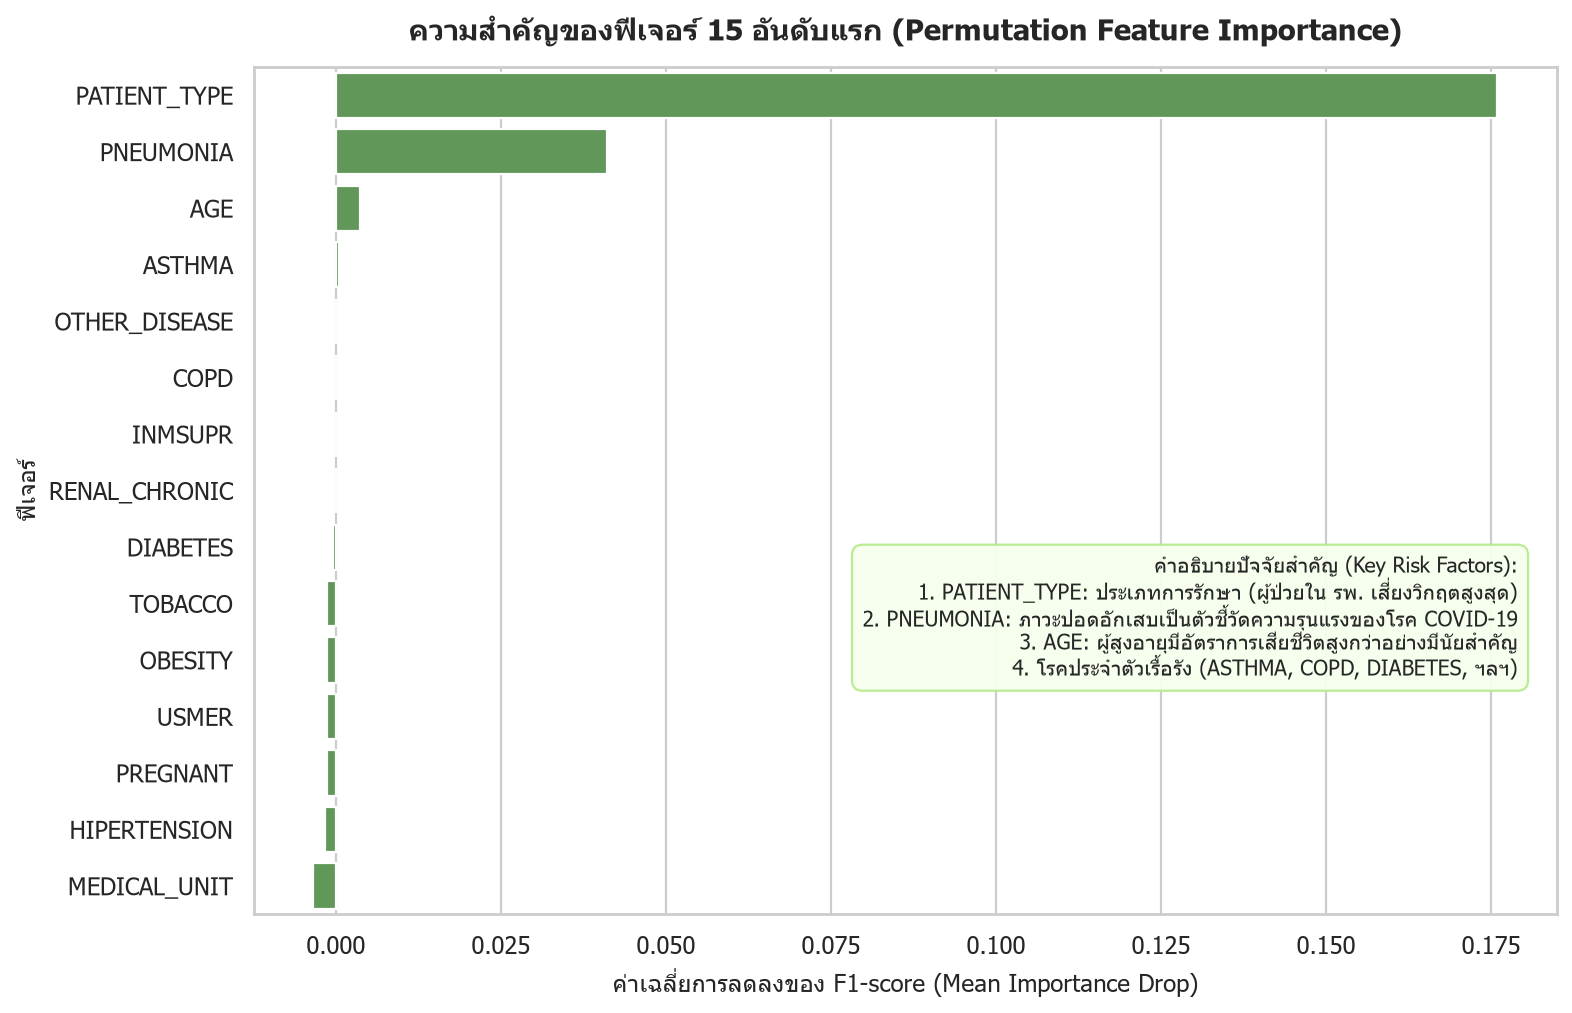

In [14]:
top_features = feat_imp.head(15)
display(top_features.style.format({"Importance": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    color="#59A14F",
    ax=ax,
)
ax.set_title("ความสำคัญของฟีเจอร์ 15 อันดับแรก (Permutation Feature Importance)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("ค่าเฉลี่ยการลดลงของ F1-score (Mean Importance Drop)", fontsize=11)
ax.set_ylabel("ฟีเจอร์", fontsize=11)

note_08 = (
    "คำอธิบายปัจจัยสำคัญ (Key Risk Factors):\n"
    "1. PATIENT_TYPE: ประเภทการรักษา (ผู้ป่วยใน รพ. เสี่ยงวิกฤตสูงสุด)\n"
    "2. PNEUMONIA: ภาวะปอดอักเสบเป็นตัวชี้วัดความรุนแรงของโรค COVID-19\n"
    "3. AGE: ผู้สูงอายุมีอัตราการเสียชีวิตสูงกว่าอย่างมีนัยสำคัญ\n"
    "4. โรคประจำตัวเรื้อรัง (ASTHMA, COPD, DIABETES, ฯลฯ)"
)
ax.text(
    0.97, 0.35, note_08,
    transform=ax.transAxes, ha="right", va="center",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#F6FFED", edgecolor="#B7EB8F", alpha=0.95)
)
fig.tight_layout()
save_figure(fig, "08_feature_importance.png")
plt.show()

## 14. บันทึกผลการทดลอง

ไฟล์ `results/svm_metrics.json` เก็บผลที่ `model_comparison.ipynb` จะนำไปเปรียบเทียบกับ Decision Tree ภายหลัง

In [15]:
best_index = grid_search.best_index_
best_params = {
    name.replace("classifier__", ""): value
    for name, value in grid_search.best_params_.items()
}

final_metrics = dict(test_metrics)
final_metrics.update(
    {
        "model_name": "Support Vector Machine",
        "selection_metric": "F1-score of Died class",
        "best_params": best_params,
        "cv_best_f1": float(grid_search.best_score_),
        "cv_best_pr_auc": float(grid_search.cv_results_["mean_test_pr_auc"][best_index]),
        "cv_best_recall": float(grid_search.cv_results_["mean_test_recall"][best_index]),
        "grid_search_seconds": float(search_seconds),
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
        "input_feature_count": int(len(FEATURE_COLUMNS)),
        "encoded_feature_count": int(len(best_svm.named_steps["preprocessor"].get_feature_names_out())),
        "support_vectors_count": {"Survived": int(n_support[0]), "Died": int(n_support[1]), "Total": int(n_support.sum())},
        "duplicate_rows_audit": int(raw_df.duplicated().sum()),
        "dummy_baseline": {
            "accuracy": dummy_metrics["accuracy"],
            "precision": dummy_metrics["precision"],
            "recall": dummy_metrics["recall"],
            "f1_score": dummy_metrics["f1_score"],
            "roc_auc": dummy_metrics["roc_auc"],
            "pr_auc": dummy_metrics["pr_auc"],
        },
    }
)

save_metrics(final_metrics, METRICS_PATH)
print(f"บันทึกผลไว้ที่: {METRICS_PATH}")

บันทึกผลไว้ที่: C:\Users\panra\OneDrive\Desktop\project\kaggle-model\results\svm_metrics.json


## สรุป

การสรุปว่าโมเดลใดดีกว่าจะทำหลังจากทั้งสองโมเดลพร้อมแล้ว โดยใช้ test set เดียวกันและพิจารณาตามลำดับ:

1. F1-score ของคลาส Died
2. PR-AUC
3. Recall ของคลาส Died
4. Precision
5. Accuracy ใช้ประกอบเท่านั้น

ขั้นตอนถัดไปคือเปิด Pull Request ของ SVM และนำผลลัพธ์ไปเปรียบเทียบใน `notebooks/model_comparison.ipynb`